# CURIA gene diagnostics

Point this at a **CURIA run output directory** and a **gene**, then *Run All*.

It draws three things, top-to-bottom:

1. **Reference island landscape** — every scanned reference island as a rectangle
   at its true genomic position and width (tiny islands *look* tiny), coloured by
   its signal/noise score.
2. **Query island landscape** — the same for the islands scanned in the projected
   query region(s).
3. **Aligned islands** — reference (top) and query (bottom) tracks with the
   pipeline's accepted island pairs joined by lines, each labelled with its match
   distance (`diag_mmd`; **lower = better**).

If a gene has several projections (chains), the best-scoring one is chosen
automatically unless you pin `CHAIN_ID`. The last section is a **what-if** that
lets you re-wire pairings by hand and see the effect on synteny.

> `diag_mmd` is a *distance*, not a similarity — smaller is a tighter match.
> Coordinates in every file are 0-based half-open.

In [1]:
# ============================================================
#  CONFIGURATION  — edit these, then Run All
# ============================================================
GENE       = "NEAT1"                            # gene symbol, ENSG…, or U_ENSG…
OUTPUT_DIR = "../preprint_results/hg38_vs_rn7"  # human FIRRE projected to mouse (mm39)
CHAIN_ID   = None                                # None -> auto-pick best projection; else "22"

# Optional BioMart TSV (columns: "Gene stable ID", "Gene name") to map symbol <-> ENSG.
# Leave None to work directly with ENSG / U_ENSG ids.
GENE_NAMES_TSV = "../input_data/reference_annotation/hg38_gene_names.txt"

In [2]:
# ------------------------------------------------------------------ imports
import json, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})

GOOD = mpl.colormaps["viridis"]            # ref/query island score  (high = bright)
DIST = mpl.colormaps["RdYlGn_r"]           # match distance          (low  = green)


def _read_bed12(path):
    """Minimal BED reader -> DataFrame(chrom,start,end,name,strand)."""
    path = Path(path)
    rows = []
    if path.exists():
        for line in path.read_text().splitlines():
            if not line.strip():
                continue
            p = line.split("\t")
            rows.append(dict(chrom=p[0], start=int(p[1]), end=int(p[2]),
                             name=p[3], strand=p[5] if len(p) > 5 else "."))
    return pd.DataFrame(rows, columns=["chrom", "start", "end", "name", "strand"])


class Run:
    """Lazy holder for the parsed contents of one CURIA output directory."""
    def __init__(self, d):
        self.dir = Path(d)
        j = lambda p: json.load(open(self.dir / p))
        self.ref_data  = j("preprocessed_reference_data.json")
        self.clusters  = j("mappings/query_regions_clusters.json")
        self.u2q       = j("mappings/union_to_query.json")
        self.aln       = pd.read_csv(self.dir / "island_alignment_results.tsv", sep="\t")
        qa = self.dir / "query_annotation"
        self.raw_query = _read_bed12(qa / "raw_query_islands.bed")
        self.raw_ref   = _read_bed12(qa / "raw_reference_islands.bed")
        ct = self.dir / "toga_results" / "original_toga_classification_table.tsv"
        self.toga = pd.read_csv(ct) if ct.exists() else None   # NOTE: this one is CSV

    def __repr__(self):
        return (f"Run({self.dir}) — {len(self.ref_data)} genes, "
                f"{len(self.aln)} matched island pairs, "
                f"{len(self.clusters)} query regions"
                + ("" if self.toga is not None else "  [no TOGA table]"))


run = Run(OUTPUT_DIR)
run

Run(../preprint_results/hg38_vs_rn7) — 28544 genes, 12084 matched island pairs, 23737 query regions

In [3]:
# ------------------------------------------------------------ resolve gene id
def _symbol_maps(names_tsv):
    sym2ens, ens2sym = {}, {}
    if names_tsv and Path(names_tsv).exists():
        for line in Path(names_tsv).read_text().splitlines()[1:]:
            p = line.split("\t")
            if len(p) >= 2 and p[1]:
                sym2ens.setdefault(p[1], p[0])
                ens2sym.setdefault(p[0], p[1])
    return sym2ens, ens2sym


_core = lambda s: re.sub(r'\.\d+$', '', s.replace("U_", ""))   # strip "U_" and version


def resolve_gene(gene, run, names_tsv=None):
    """Normalise a symbol / ENSG / U_ENSG string to the exact key used in this run.

    Tolerant of Ensembl version suffixes: 'FIRRE', 'ENSG00000213468' and
    'U_ENSG00000213468' all resolve to e.g. 'U_ENSG00000213468.8' if that is
    the key present in the run.
    """
    g = gene.strip()
    sym2ens, ens2sym = _symbol_maps(names_tsv)
    keys = list(run.ref_data)
    by_core = {}                              # ENSG (no version) -> full key
    for k in keys:
        by_core.setdefault(_core(k), k)

    if g.startswith("U_") or g.startswith("ENSG"):
        want = _core(g)
    elif g in sym2ens:
        want = _core(sym2ens[g])
    else:
        want = None

    gid = g if g in run.ref_data else by_core.get(want)   # prefer exact, else version-agnostic
    if gid is None:
        raise KeyError(
            f"{gene!r} (core {want!r}) not found in this run.\n"
            f"Genes available (first 15): {sorted(keys)[:15]}"
            + ("" if names_tsv else "\n(Provide GENE_NAMES_TSV to look genes up by symbol.)"))
    sym = ens2sym.get(_core(gid))
    return gid, sym


gene_id, gene_sym = resolve_gene(GENE, run, GENE_NAMES_TSV)
label = f"{gene_sym} ({gene_id})" if gene_sym else gene_id
print("gene         :", label)
print("biotype      :", run.ref_data[gene_id].get("biotype", "?"))
print("locus length :", run.ref_data[gene_id].get("total_length"), "bp")
print("ref islands  :", len(run.ref_data[gene_id]["islands"]))

gene         : NEAT1 (U_ENSG00000245532.13)
biotype      : ?
locus length : 22743 bp
ref islands  : 23


In [4]:
# --------------------------------------------- gather this gene's islands & projections
# Reference islands (all scanned), sorted 5'->3' by genomic start.
ref_islands = sorted(run.ref_data[gene_id]["islands"], key=lambda i: i["start"])
ref_strand  = ref_islands[0]["strand"] if ref_islands else 1

# Projections: every merged_transcripts entry across all query regions for this gene.
proj = []
for reg, v in run.clusters.items():
    for t in v["merged_transcripts"]:
        if t["transcript_id"] == gene_id:
            mr = v["merged_region"]
            proj.append(dict(region=reg, chain_id=str(t["chain_id"]),
                             chrom=mr["chrom"], start=mr["start"],
                             end=mr["end"], strand=mr["strand"]))
proj_df = pd.DataFrame(proj)

# Accepted island pairs for this gene, tagged with the chain they belong to
# (join by query-coordinate containment — the TSV itself carries no chain_id).
pairs = run.aln[run.aln.gene_id == gene_id].copy()
def _chain_of(r):
    for p in proj:
        if (r.query_chrom == p["chrom"] and
                r.query_start >= p["start"] and r.query_end <= p["end"]):
            return p["chain_id"]
    return None
pairs["chain_id"] = pairs.apply(_chain_of, axis=1) if len(pairs) else pd.Series(dtype=object)

# Pick which projection (chain) to inspect.
def pick_chain():
    chains = sorted(proj_df.chain_id.unique()) if len(proj_df) else []
    if CHAIN_ID is not None:
        return str(CHAIN_ID)
    if run.toga is not None and chains:                     # best TOGA orthology prob
        t = run.toga[(run.toga.transcript_id == gene_id) &
                     (run.toga.chain_id.astype(str).isin(chains))]
        if len(t):
            return str(t.sort_values("pred", ascending=False).iloc[0].chain_id)
    if len(pairs) and pairs.chain_id.notna().any():         # else tightest mean distance
        return pairs.dropna(subset=["chain_id"]).groupby("chain_id").diag_mmd.mean().idxmin()
    return chains[0] if chains else None

chain_id = pick_chain()

# Restrict everything to the chosen chain (unique regions, order preserved).
sel_regions = list(dict.fromkeys(p["region"] for p in proj if p["chain_id"] == chain_id))
sel_pairs   = pairs[pairs.chain_id == chain_id].copy() if chain_id else pairs.copy()

# Query islands scanned in the chosen region(s). Select by genomic containment in
# the merged-region span(s), NOT by gene-id name prefix: a merged region can be
# shared between genes, so its islands may be named after a *different* gene while
# still being valid match targets for this one (else matched pairs go undrawn).
sel_spans = [run.clusters[r]["merged_region"] for r in sel_regions]
def _in_spans(r):
    return any(r.chrom == s["chrom"] and r.start >= s["start"] and r.end <= s["end"]
               for s in sel_spans)
query_isl = (run.raw_query[run.raw_query.apply(_in_spans, axis=1)].sort_values("start")
             if sel_spans and len(run.raw_query) else run.raw_query.iloc[0:0])
q_strand   = proj_df[proj_df.chain_id == chain_id].strand.iloc[0] if chain_id and len(proj_df) else 1

print(f"projections for {gene_id}:")
print(proj_df.to_string(index=False) if len(proj_df) else "  (none)")
print(f"\n-> inspecting chain {chain_id!r}  |  regions {sel_regions}")
print(f"   reference islands : {len(ref_islands)}")
print(f"   query islands     : {len(query_isl)}")
print(f"   accepted pairs    : {len(sel_pairs)}")
if chain_id is not None and CHAIN_ID is None and len(proj_df.chain_id.unique()) > 1:
    print(f"   (auto-picked; set CHAIN_ID to one of {sorted(proj_df.chain_id.unique())} to override)")

projections for U_ENSG00000245532.13:
                   region chain_id chrom     start       end  strand
query_merged_region_10297       23  chr1 203112191 203113848      -1
query_merged_region_10298       23  chr1 203113084 203121244      -1
query_merged_region_10298       23  chr1 203113084 203121244      -1
query_merged_region_10298       23  chr1 203113084 203121244      -1
query_merged_region_10298       23  chr1 203113084 203121244      -1
query_merged_region_10298       23  chr1 203113084 203121244      -1
query_merged_region_10298       23  chr1 203113084 203121244      -1
query_merged_region_10298       23  chr1 203113084 203121244      -1
query_merged_region_10299       23  chr1 203123502 203135233      -1
query_merged_region_10299       23  chr1 203123502 203135233      -1
query_merged_region_10299       23  chr1 203123502 203135233      -1
query_merged_region_10299       23  chr1 203123502 203135233      -1
query_merged_region_10299       23  chr1 203123502 203135233     

## 1 · Reference island landscape

Each rectangle is one scanned reference island drawn at its **true** genomic
span, so proportions are honest — many islands are far smaller than the gaps
between them. A thin tick marks the centre of every island so tiny ones stay
findable. Colour = the island's signal score (brighter = stronger).

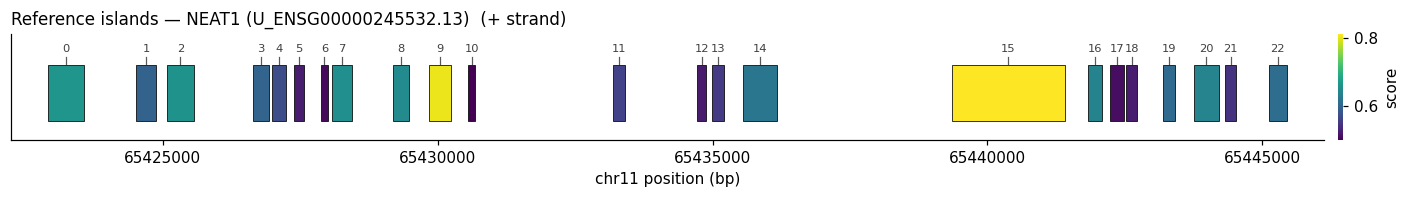

In [5]:
def plot_landscape(islands, *, title, score_key, strand, cmap=GOOD):
    """Draw islands as true-width rectangles along a genomic axis."""
    if not islands:
        print(f"{title}: no islands"); return
    starts = np.array([i["start"] for i in islands], float)
    ends   = np.array([i["end"]   for i in islands], float)
    scores = np.array([float(i.get(score_key, 0) or 0) for i in islands])
    lo, hi = starts.min(), ends.max(); span = max(hi - lo, 1)
    norm = mpl.colors.Normalize(scores.min(), scores.max() if scores.max() > scores.min() else scores.min() + 1)

    fig, ax = plt.subplots(figsize=(13, 1.9))
    for k, (s, e, sc) in enumerate(zip(starts, ends, scores)):
        ax.add_patch(Rectangle((s, 0), max(e - s, 1), 1, facecolor=cmap(norm(sc)),
                               edgecolor="black", linewidth=.5, zorder=3))
        cx = (s + e) / 2
        ax.plot([cx, cx], [1.02, 1.14], color="0.35", lw=.8, zorder=2)   # centre tick
        ax.text(cx, 1.2, str(k), ha="center", va="bottom", fontsize=7.5, color="0.25")
    ax.set_xlim(lo - .03 * span, hi + .03 * span); ax.set_ylim(-0.35, 1.55)
    ax.set_yticks([])
    arrow = "  (- strand, 5'->3' is right->left)" if strand == -1 else "  (+ strand)"
    ax.set_title(title + arrow, loc="left", fontsize=11)
    ax.set_xlabel(f"{islands[0]['chrom']} position (bp)")
    ax.ticklabel_format(axis="x", style="plain", useOffset=False)
    fig.colorbar(mpl.cm.ScalarMappable(norm, cmap), ax=ax, fraction=.025,
                 pad=.01, label="score").outline.set_visible(False)
    plt.tight_layout(); plt.show()


plot_landscape(ref_islands, title=f"Reference islands — {label}",
               score_key="score", strand=ref_strand)

## 2 · Query island landscape

The islands independently scanned in the projected query region(s) for the
chosen chain. These are **candidates** — not yet matched to anything.

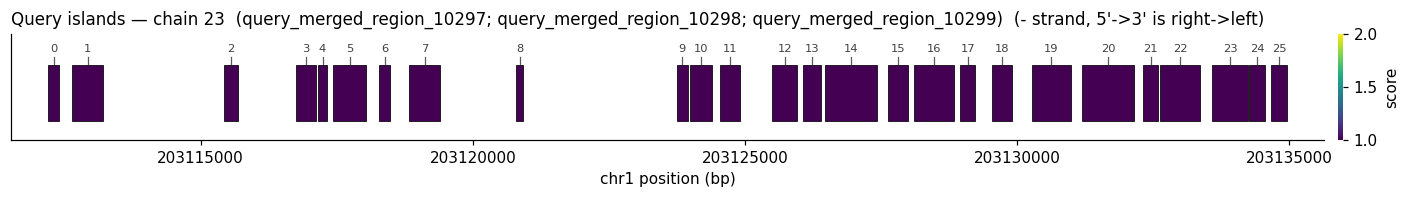

(query islands carry no per-island score in the default output; colour is uniform here.)


In [6]:
q_for_plot = [dict(chrom=r.chrom, start=r.start, end=r.end, strand=r.strand, score=1.0)
              for r in query_isl.itertuples()]
plot_landscape(q_for_plot,
               title=f"Query islands — chain {chain_id}  ({'; '.join(sel_regions)})",
               score_key="score", strand=q_strand, cmap=GOOD)
if q_for_plot:
    print("(query islands carry no per-island score in the default output; "
          "colour is uniform here.)")

## 3 · Aligned islands

Reference track on top, query track on bottom, both normalised to their own
locus and oriented 5'→3'. Faint grey bars are *all* scanned islands; coloured
bars are the ones the pipeline matched. Each connecting line is an accepted pair,
coloured and labelled by `diag_mmd` (**green/low = tight match**).

Lines that **cross** break collinearity (synteny) and are worth a closer look —
they are flagged below the plot.

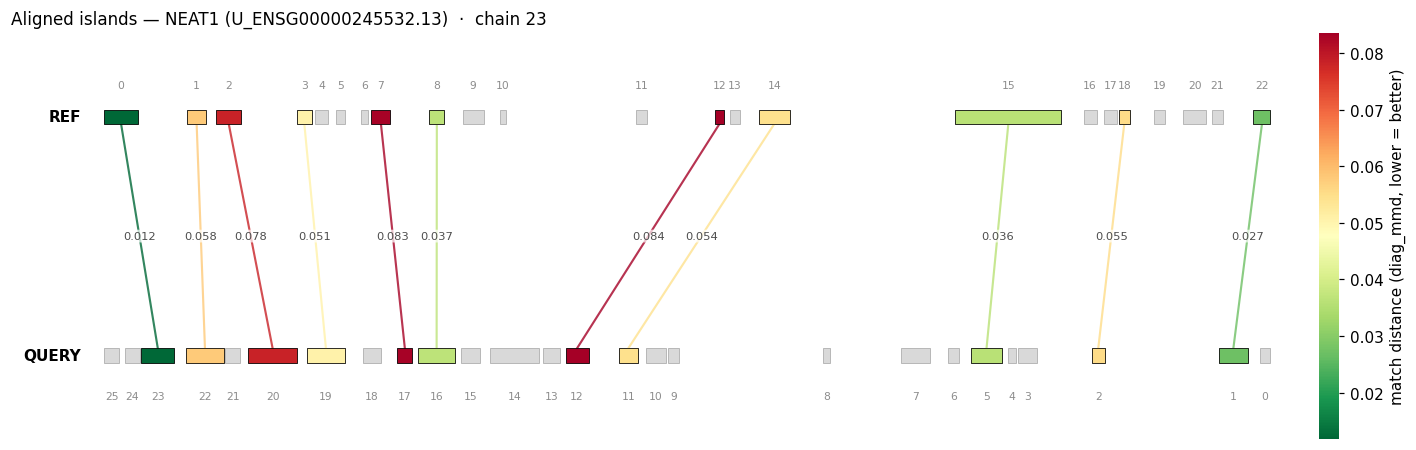

In [7]:
def _axis(lo, hi, strand):
    span = max(hi - lo, 1)
    return (lambda p: (1 - (p - lo) / span) if strand == -1 else (p - lo) / span), span


def _match_index(pair, islands, side):
    """Map a TSV pair row to the index of the island it overlaps most (by coord)."""
    s, e = (pair.ref_start, pair.ref_end) if side == "ref" else (pair.query_start, pair.query_end)
    best, bj = -1, None
    for j, i in enumerate(islands):
        ov = min(e, i["end"]) - max(s, i["start"])
        if ov > best:
            best, bj = ov, j
    return bj


def build_matches(ref_islands, query_isl, sel_pairs):
    q_isl = [dict(chrom=r.chrom, start=r.start, end=r.end) for r in query_isl.itertuples()]
    m, dropped = [], []
    for p in sel_pairs.itertuples():
        ri = _match_index(p, ref_islands, "ref")
        qi = _match_index(p, q_isl, "query")
        if ri is None or qi is None:          # pair coords overlap no drawn island
            dropped.append((f"{p.ref_chrom}:{p.ref_start}-{p.ref_end}",
                            f"{p.query_chrom}:{p.query_start}-{p.query_end}"))
            continue
        m.append(dict(ref_i=ri, q_i=qi, dist=p.diag_mmd,
                      ref_label=p.ref_island, q_label=p.query_island,
                      ref_start=p.ref_start, ref_end=p.ref_end,
                      q_start=p.query_start, q_end=p.query_end))
    if dropped:
        print(f"[!] {len(dropped)} matched pair(s) could not be located among the "
              f"drawn islands and were skipped: {dropped}")
    return m, q_isl


def plot_connections(ref_islands, q_isl, matches, *, chain_id, title_extra="",
                     highlight_ref=None, cmap=DIST):
    if not ref_islands or not q_isl:
        print("Need both reference and query islands to draw connections."); return None
    r_lo = min(i["start"] for i in ref_islands); r_hi = max(i["end"] for i in ref_islands)
    q_lo = min(i["start"] for i in q_isl);       q_hi = max(i["end"] for i in q_isl)
    rx, _ = _axis(r_lo, r_hi, ref_strand)
    qx, _ = _axis(q_lo, q_hi, q_strand)
    Y_R, Y_Q, H = 1.0, 0.0, 0.06
    # only draw matches whose island indices are in range (defensive against stale data)
    matches = [m for m in matches if m.get("ref_i") is not None and m.get("q_i") is not None
               and m["ref_i"] < len(ref_islands) and m["q_i"] < len(q_isl)]
    dvals = [m["dist"] for m in matches if pd.notna(m["dist"])] or [0, 1]
    norm = mpl.colors.Normalize(min(dvals), max(max(dvals), min(dvals) + 1e-6))

    fig, ax = plt.subplots(figsize=(13, 4.2))
    # background: every scanned island, faint
    for isl, y, xf in [(ref_islands, Y_R, rx), (q_isl, Y_Q, qx)]:
        for k, i in enumerate(isl):
            a, b = sorted((xf(i["start"]), xf(i["end"])))
            ax.add_patch(Rectangle((a, y - H/2), max(b - a, .004), H,
                                   facecolor="0.85", edgecolor="0.6", lw=.4, zorder=2))
            ax.text((a + b) / 2, y + (0.11 if y == Y_R else -0.11) - (0 if y == Y_R else 0.04),
                    str(k), ha="center", va="bottom" if y == Y_R else "top",
                    fontsize=7, color="0.55")
    # matched islands + connecting lines
    for m in matches:
        ri, qi = ref_islands[m["ref_i"]], q_isl[m["q_i"]]
        ra = sorted((rx(ri["start"]), rx(ri["end"]))); qa = sorted((qx(qi["start"]), qx(qi["end"])))
        c = cmap(norm(m["dist"])) if pd.notna(m["dist"]) else "0.5"
        for (a, b), y in [(ra, Y_R), (qa, Y_Q)]:
            ax.add_patch(Rectangle((a, y - H/2), max(b - a, .004), H,
                                   facecolor=c, edgecolor="black", lw=.5, zorder=4))
        x0, x1 = (ra[0] + ra[1]) / 2, (qa[0] + qa[1]) / 2
        hot = highlight_ref is not None and m["ref_i"] == highlight_ref
        style = "-" if pd.notna(m["dist"]) else "--"
        ax.plot([x0, x1], [Y_R - H/2, Y_Q + H/2], color=c, lw=2.6 if hot else 1.4,
                ls=style, alpha=.95 if hot else .8, zorder=3 if not hot else 5)
        txt = f"{m['dist']:.3f}" if pd.notna(m["dist"]) else "?"
        ax.text((x0 + x1) / 2, 0.5, txt, ha="center", va="center",
                fontsize=7.5, color="black" if hot else "0.3",
                fontweight="bold" if hot else "normal",
                bbox=dict(boxstyle="round,pad=.12", fc="white", ec="none", alpha=.7))
    ax.text(-0.02, Y_R, "REF", ha="right", va="center", fontweight="bold", fontsize=10)
    ax.text(-0.02, Y_Q, "QUERY", ha="right", va="center", fontweight="bold", fontsize=10)
    ax.set_xlim(-0.08, 1.03); ax.set_ylim(-0.35, 1.35); ax.axis("off")
    ax.set_title(f"Aligned islands — {label}  ·  chain {chain_id}{title_extra}",
                 loc="left", fontsize=11)
    fig.colorbar(mpl.cm.ScalarMappable(norm, cmap), ax=ax, fraction=.02, pad=.01,
                 label="match distance (diag_mmd, lower = better)").outline.set_visible(False)
    plt.tight_layout(); plt.show()
    return norm


matches, q_isl = build_matches(ref_islands, query_isl, sel_pairs)
plot_connections(ref_islands, q_isl, matches, chain_id=chain_id)

In [8]:
# ---------------------------------------------------- collinearity / synteny report
def synteny_report(matches, ref_islands, q_isl):
    if len(matches) < 2:
        print("Fewer than 2 matches — nothing to check for collinearity."); return
    rx, _ = _axis(min(i["start"] for i in ref_islands),
                  max(i["end"]   for i in ref_islands), ref_strand)
    qx, _ = _axis(min(i["start"] for i in q_isl),
                  max(i["end"]   for i in q_isl), q_strand)
    rows = []
    for m in matches:
        rows.append(dict(ref=m["ref_i"], query=m["q_i"], dist=round(m["dist"], 4),
                         ref_x=rx((ref_islands[m["ref_i"]]["start"] + ref_islands[m["ref_i"]]["end"]) / 2),
                         q_x=qx((q_isl[m["q_i"]]["start"] + q_isl[m["q_i"]]["end"]) / 2)))
    df = pd.DataFrame(rows).sort_values("ref_x").reset_index(drop=True)
    # crossings: pairs out of order on the query side
    crossings = [(df.ref[a], df.ref[b]) for a in range(len(df)) for b in range(a + 1, len(df))
                 if df.q_x[a] > df.q_x[b]]
    rho = df.ref_x.corr(df.q_x, method="spearman")
    # deviation from the collinear diagonal (least-squares fit ref_x -> q_x)
    A = np.polyfit(df.ref_x, df.q_x, 1)
    df["expected_q_x"] = np.polyval(A, df.ref_x)
    df["deviation"] = (df.q_x - df.expected_q_x).round(3)
    print(f"Spearman(ref order, query order) = {rho:+.3f}   "
          f"(+1 = perfectly collinear)")
    print(f"line crossings = {len(crossings)}"
          + (f"  -> ref islands {crossings}" if crossings else "  (none)"))
    print("\nper-match table (deviation = distance off the collinear diagonal):")
    with pd.option_context("display.max_rows", None):
        print(df[["ref", "query", "dist", "deviation"]].to_string(index=False))
    flag = df[df.deviation.abs() > 0.15]
    if len(flag):
        print("\n[!] off-diagonal matches (candidate mis-pairings):",
              list(flag.ref))
    return df


synteny_df = synteny_report(matches, ref_islands, q_isl)

Spearman(ref order, query order) = +1.000   (+1 = perfectly collinear)
line crossings = 0  (none)

per-match table (deviation = distance off the collinear diagonal):
 ref  query   dist  deviation
   0     23 0.0118      0.016
   1     22 0.0580     -0.003
   2     20 0.0782      0.030
   3     19 0.0507      0.016
   7     17 0.0830      0.023
   8     16 0.0367      0.007
  12     12 0.0835     -0.095
  14     11 0.0544     -0.095
  15      5 0.0360      0.029
  18      2 0.0553      0.033
  22      1 0.0270      0.041


## 4 · What-if — re-wire a pairing

The pipeline's per-island *distance* comes from the RNA language-model
embeddings, so the true score of a hypothetical pairing can only be recomputed
by re-running the model. What we **can** inspect from the saved output is the
*geometry*: for a reference island, which query islands are plausible alternative
partners by position, and whether swapping to one breaks synteny.

Set `WHATIF` to a `{ref_island_index: query_island_index}` mapping (indices are
the numbers on the grey bars in plot 3). Islands not listed keep their accepted
partner; map to `None` to drop a pair. The plot redraws with your wiring and the
synteny report reruns so you can compare crossings / deviation against the
pipeline's choice above.

In [9]:
# For a reference island, rank query islands by how close they sit to the
# collinear diagonal implied by the *other* accepted matches (position-only proxy).
def alternative_partners(ref_i, matches, ref_islands, q_isl, top=5):
    rx, _ = _axis(min(i["start"] for i in ref_islands),
                  max(i["end"]   for i in ref_islands), ref_strand)
    qx, _ = _axis(min(i["start"] for i in q_isl),
                  max(i["end"]   for i in q_isl), q_strand)
    others = [(rx((ref_islands[m["ref_i"]]["start"]+ref_islands[m["ref_i"]]["end"])/2),
               qx((q_isl[m["q_i"]]["start"]+q_isl[m["q_i"]]["end"])/2))
              for m in matches if m["ref_i"] != ref_i]
    rxi = rx((ref_islands[ref_i]["start"] + ref_islands[ref_i]["end"]) / 2)
    if len(others) >= 2:
        A = np.polyfit([o[0] for o in others], [o[1] for o in others], 1)
        exp = np.polyval(A, rxi)
    else:
        exp = rxi
    cand = []
    for qi, q in enumerate(q_isl):
        qxi = qx((q["start"] + q["end"]) / 2)
        cand.append((qi, round(abs(qxi - exp), 3)))
    cand.sort(key=lambda t: t[1])
    cur = next((m["q_i"] for m in matches if m["ref_i"] == ref_i), None)
    print(f"ref island {ref_i}: pipeline paired it with query {cur}.")
    print(f"nearest-to-diagonal query candidates (|offset|): {cand[:top]}")
    return cand


# Example: inspect alternatives for the first matched reference island.
if matches:
    _ = alternative_partners(matches[0]["ref_i"], matches, ref_islands, q_isl)

ref island 0: pipeline paired it with query 23.
nearest-to-diagonal query candidates (|offset|): [(24, np.float64(0.001)), (25, np.float64(0.019)), (23, np.float64(0.021)), (22, np.float64(0.061)), (21, np.float64(0.085))]


In [10]:
# ------------------------------------------------- apply a manual re-wiring
WHATIF = {}          # e.g. {3: 5, 7: None}  -> pair ref 3 with query 5, drop ref 7

def apply_whatif(matches, overrides):
    out, seen = [], set()
    for m in matches:
        if m["ref_i"] in overrides:
            seen.add(m["ref_i"])
            tgt = overrides[m["ref_i"]]
            if tgt is None:
                continue                      # dropped
            nm = dict(m); nm["q_i"] = tgt; nm["dist"] = np.nan   # unknown w/o model
            out.append(nm)
        else:
            out.append(dict(m))
    for ref_i, tgt in overrides.items():      # brand-new pairings
        if ref_i not in seen and tgt is not None:
            out.append(dict(ref_i=ref_i, q_i=tgt, dist=np.nan,
                            ref_label=f"R{ref_i}", q_label=f"Q{tgt}"))
    return out

if WHATIF:
    wf = apply_whatif(matches, WHATIF)
    print("what-if wiring:", {m["ref_i"]: m["q_i"] for m in wf}, "\n")
    plot_connections(ref_islands, q_isl, wf, chain_id=chain_id,
                     title_extra="  [WHAT-IF]")
    synteny_report(wf, ref_islands, q_isl)
    print("\nNB: distances shown as NaN for re-wired pairs — a real diag_mmd "
          "requires re-running the RNA language model on those island windows.")
else:
    print("WHATIF is empty — set it to a {ref_index: query_index} mapping to explore.")

WHATIF is empty — set it to a {ref_index: query_index} mapping to explore.
